In [1]:
import Pkg
Pkg.activate("../../../FinancialPlanner")

  Activating project at `c:\Users\matsz\programowanie\Optymalizacja_portfela\FinancialPlanner`


In [2]:
using Revise
using LinearAlgebra
using Distributions
using Random
using StatsPlots
using PDMats
using StatsBase
using Base.Iterators
using DataFrames, TimeSeries, XLSX
using PrettyTables

In [3]:
using Revise

includet("../../src/ESGModels/msvar.jl")
includet("../../src/ESGModels/msvar_gibs.jl")
includet("../../src/ESGModels/msvar_simulate.jl") 
include("../VARs/utils.jl")

calculate_bond_returns

In [85]:
df = DataFrame(XLSX.readtable("../../data/usa_data.xlsx", "Data", infer_eltypes=true))
data_source = collapse(TimeArray(df; timestamp = :Date), Dates.month, last)

freq = 12
#:Price_10Y
returns = percentchange(data_source[:Total_Stock], :log)
cpi = percentchange(data_source[:CPI], :log) 

real_t_bill = log1p.(data_source[:T_Bill])./freq .- cpi

excess_returns = returns .- log1p.(data_source[:T_Bill]./freq)

dy = log.(data_source[:Dividend]) .- log.(data_source[:Stock_Price])

term = data_source[:Yeld_10Y] ./freq .- data_source[:T_Bill] ./freq

#data = merge(excess_returns, real_t_bill, dy, term, log1p.(data_source[:T_Bill]))
data = merge(excess_returns, real_t_bill, term)

start = Date(1985, 01,01)
end_d = Date(2024, 12, 31)
s_data = to(from(data, start),end_d)

display(returns_summarystats(s_data, freq)) 
display(cor(values(s_data)))

,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
Total_Stock_T_Bill,0.1536,1.458,0.0785,0.4179,-2.9619,-0.9571,-0.2002,0.0138,2.9215,0.5107,0.1321
T_Bill_CPI,0.0126,0.2387,0.0034,0.0303,-0.1559,-0.0771,-0.0226,0.5882,2.2886,0.2675,0.0098
Yeld_10Y_T_Bill,0.0035,0.0394,0.0163,0.0262,-0.015,-0.2687,0.0074,0.9614,-0.6079,4.6663,0.0163


nothing

3×3 Matrix{Float64}:
  1.0        -0.0903778  -0.0483738
 -0.0903778   1.0        -0.143506
 -0.0483738  -0.143506    1.0

In [107]:
mean(returns[Date(2014,01,01) : Date(2024, 12, 31)]) .* 12

1×1 TimeArray{Float64, 1, Date, Vector{Float64}} 2024-07-01 to 2024-07-01
┌────────────┬─────────────┐
│            │ Total_Stock │
├────────────┼─────────────┤
│ 2024-07-01 │    0.121358 │
└────────────┴─────────────┘

In [86]:
assets_names = colnames(s_data)

3-element Vector{Symbol}:
 :Total_Stock_T_Bill
 :T_Bill_CPI
 :Yeld_10Y_T_Bill

In [91]:
Y, X = prepare_var_data(values(s_data), p=1, X = Matrix{Float64}(undef, 0, 0), add_intercept = true)

([0.005210776914104084 0.0028550106490825384 0.003033333333333333; -0.006399572897336269 0.002125450693431407 0.002608333333333335; … ; 0.030786207595812742 0.004087424285638979 -0.0007333333333333337; 0.008007174130421721 0.0041400960802971095 -0.0009250000000000009], [1.0 0.06830780222021252 0.001499887646889097 0.002841666666666667; 1.0 0.005210776914104084 0.0028550106490825384 0.003033333333333333; … ; 1.0 0.04362223443801919 0.00392657537072938 -0.000616666666666666; 1.0 0.030786207595812742 0.004087424285638979 -0.0007333333333333337])

In [113]:
n_burn = 50_000
n_sample = 2000
n = 2
T = size(Y,1)
Β0 = (inv(transpose(X) * X) * transpose(X) * Y)
Σ0 = transpose((Y -  X * Β0)) * (Y -  X * Β0) / (T- n -1)

tm0 = [.9 .1; .1 .9]

regimes, t_m, Β_post, Σ_post = msvar(Y, X, tm0 , [Β0', Β0'], [Σ0, Σ0], n_burn, n_sample)

([1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1], [0.9491349489643043 0.19925843874798968; 0.9608799256583799 0.19530796876313036; … ; 0.9336854185638809 0.15663053182290732; 0.937297078629053 0.20845268342566625;;; 0.050865051035695684 0.8007415612520105; 0.03912007434161997 0.8046920312368697; … ; 0.06631458143611917 0.8433694681770928; 0.06270292137094707 0.7915473165743337], Vector{Any}[[[0.017905585561695036 -0.11717404228710594 -0.21415003679766942 -3.3268719077251587; 0.00041791311456430407 -0.004905777797642211 0.6593046664856982 -0.08572430767006231; -4.298964356738155e-5 0.0013661150481925053 -0.013413592715493996 0.9917872161537546], [-0.021789990912408352 0.05028182486022958 -1.1835409812481865 -6.3813432673333725; 0.001054276354804846 -0.023145165104532975 0.3595396070746896 -0.6557439209948568; 0.00018241221525798148 0.00018804393875319631 -0.021952385343811845 0.9235056434888574]], [[0.022815218764723286 -0.20322462509349787 0.05667612368751726 -6.139528554167742; 1.386

In [114]:
inv(Matrix(I(3)) - Β0[2:end,:])' * Β0[1,:] .*12

3-element Vector{Float64}:
 0.08232752547861533
 0.00474732935748966
 0.012994090274119168

473-element Vector{Date}:
 1985-02-01
 1985-03-01
 1985-04-01
 1985-05-01
 1985-06-01
 1985-07-01
 1985-08-01
 1985-09-01
 1985-10-01
 1985-11-01
 ⋮
 2023-10-01
 2023-11-01
 2023-12-01
 2024-01-01
 2024-02-01
 2024-03-01
 2024-04-01
 2024-05-01
 2024-06-01

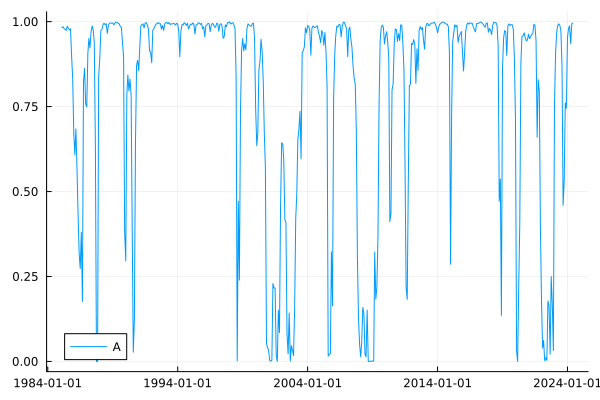

In [135]:
r1 = [count(x -> x ==1, regimes[:,t]) for t in 1:T-1] / n_sample
r1 = TimeArray(timestamp(s_data[2:end-1]), r1)
plot(r1)

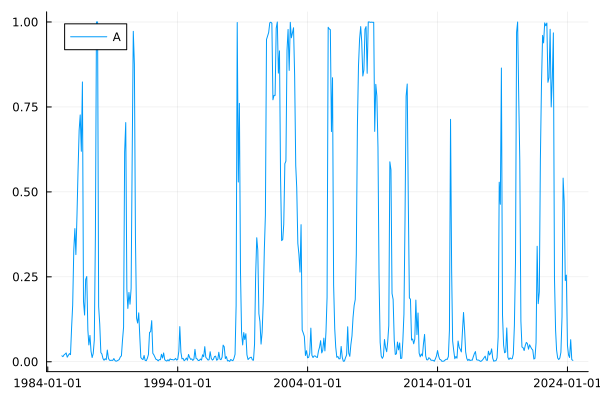

In [137]:
r2 = [count(x -> x ==2, regimes[:,t]) for t in 1:T-1] / n_sample
r2 = TimeArray(timestamp(s_data[2:end-1]), r2)
plot(r2)

In [142]:
transition_matrix = mean(t_m, dims=1)[1,:,:]
display(transition_matrix)
B1 = mean(map(x -> x[1],Β_post))
B2 = mean(map(x -> x[2],Β_post))
display(B1)
display(B2)

cov1_mean = mean(map(x -> x[1], Σ_post))
cov2_mean = mean(map(x -> x[2], Σ_post))




2×2 Matrix{Float64}:
 0.942442  0.0575584
 0.213628  0.786372

3×4 Matrix{Float64}:
 0.0184767    -0.182649      0.198665    -1.94526
 0.000380037  -0.000612323   0.616049    -0.164258
 9.46467e-7    0.00085831   -0.00686644   0.979763

3×4 Matrix{Float64}:
 -0.0139951     0.0582831    -0.384641    -4.65791
  8.45835e-5   -0.00588332    0.523613    -0.141721
  0.000124382  -0.000103029  -0.00963841   0.927451

3×3 Matrix{Float64}:
  0.00469648  -6.06516e-5  3.10235e-7
 -6.06516e-5   2.09927e-5  1.65779e-7
  3.10235e-7   1.65779e-7  1.22994e-7

In [164]:
display("state one unconditional mean")
display(inv(Matrix(I(3)) - B1[:,2:end]) * B1[:,1] * 12)

display("state two unconditional mean")
display(inv(Matrix(I(3)) - B2[:,2:end]) * B2[:,1] * 12)

"state one unconditional mean"

3-element Vector{Float64}:
 0.18079553091702172
 0.009438928571334396
 0.005026603396852976

"state two unconditional mean"

3-element Vector{Float64}:
 -0.2822392519495784
 -0.0006490980979227349
  0.02106058651872455

In [152]:
n_steps = 300
n_scenarios = 2000
states_zero = [values(r1[end])[1], values(r2[end])[1]]
scenarios_regimes = simulate_regimes(states_zero, transition_matrix, n_steps, n_scenarios)
scenarios_returns = simulate_msvar_returns(scenarios_regimes, [B1, B2], [cov1_mean, cov2_mean], X[end,2:4], n_steps, 2000)

3×300×2000 Array{Float64, 3}:
[:, :, 1] =
 -0.0115992     0.0296202    -0.00571657  …  -0.0215097    0.0601832
  0.00342969    0.00600435    0.00148368     -0.00145257   0.000854029
 -0.000600002  -0.000797518  -0.00062548      0.000553794  0.000245591

[:, :, 2] =
  0.00930303   -0.0152537    0.0279087    …  0.019746    -0.16885
 -0.000777723  -0.00146043   0.000257359     0.0033754   -0.00909147
 -0.00103231   -0.00115226  -0.00131373      0.00220502   0.00229709

[:, :, 3] =
  0.0358702    -0.00209181    0.0207494   …  0.0212873   -0.0589456
  0.00400122    0.00429168    0.00257626     0.00154422   1.91435e-5
 -0.000527299  -0.000378575  -0.0002556      0.00152809   0.00141822

;;; … 

[:, :, 1998] =
 -0.00233076    0.0138135    …  0.0651932   -0.00529798  0.0366185
  0.00519532   -0.0024842       0.00118537   0.00250392  0.0012421
 -0.000963176  -0.000653159     0.00101352   0.00114869  0.00143416

[:, :, 1999] =
  0.009145    -0.0307478   -0.112417     …  0.00231216  -0.168617
  0

In [153]:
periods = [1,5,10,25]
real_returns = scenarios_returns[1, :,:] + scenarios_returns[2, :,:]
ret_on_years = cumsum(real_returns, dims=1)[freq * periods, :] ./ periods

quantile(ret_on_years[1,:], [.05, .25, .5, .75, .95])'


1×5 adjoint(::Vector{Float64}) with eltype Float64:
 -0.122245  0.0926434  0.180658  0.260459  0.369092

In [154]:
periods = [1,5, 10, 25]
ret_in_years = cum_returns_in_periods(scenarios_returns, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))
n_assets = length(assets_names)
for a in 1:n_assets
    print_scenarios_percentiles(ret_in_years[a, :, :], [.05, .25, .5, .75, .95], string.(periods), string.(assets_names[a]))
end  

,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,0.1461,0.0172,-0.0063
5,0.114,0.0104,0.0017
10,0.1021,0.0082,0.006
25,0.092,0.0064,0.0095


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,0.1529,0.0226,0.0058
5,0.0807,0.0122,0.0084
10,0.0609,0.0092,0.0079
25,0.0402,0.006,0.0059


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,-1.0609,-0.1108,0.2321
5,-0.5656,-0.0625,0.0337
10,-0.3614,0.0482,-0.1241
25,-0.1195,0.0292,-0.1507


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,2.6877,0.5209,0.1637
5,0.4737,0.134,0.0231
10,0.245,0.3003,0.0776
25,-0.0073,-0.023,0.0924


,0.05,0.25,0.5,0.75,0.95
1,-0.1449,0.0729,0.1648,0.2432,0.3471
5,-0.0295,0.0653,0.1226,0.1728,0.2319
10,-0.0047,0.0618,0.1058,0.1454,0.1965
25,0.0242,0.0655,0.0929,0.1193,0.1585


,0.05,0.25,0.5,0.75,0.95
1,-0.0201,0.0026,0.0172,0.0324,0.0536
5,-0.0106,0.0022,0.0105,0.0184,0.0305
10,-0.0069,0.0019,0.0082,0.0143,0.0228
25,-0.0033,0.0023,0.0064,0.0106,0.0163


,0.05,0.25,0.5,0.75,0.95
1,-0.0157,-0.0101,-0.0067,-0.0026,0.0036
5,-0.0121,-0.0039,0.0016,0.0074,0.0153
10,-0.0074,0.0007,0.006,0.0113,0.0187
25,-0.0005,0.0057,0.0096,0.0136,0.019


###TODO

- plot regimes probs with dates
- tranfrom posterior mean, to model
- print model summary from means

In [112]:
b = .6
a = 2

1/(1-b) * a


5.0